In the preivous lab session, we have learned how to set up differential privacy to defense against differential attacks in a scenario of database query. In this lab session, we involve a more complex privacy sceanrios, social network. We investigate the personalized privacy protection within the social network.


**Objectives**

1. Consolidate the understanding of the definition and importance of personalized privacy
2. Create a social network, understand the relationships between the entities.
3. Create privacy measurement among the social network.
4. Implement **personalized privacy protection** based on the privacy measurement.

# Preparation
## Step 1: create a social network

Requirement: **NetworkX** and **Matplotlib** libraries in Python. 


**NetworkX** is a Python library that facilitates the creation, manipulation, and analysis of complex networks of nodes and edges. Developed initially in 2002, this library is particularly useful for the study of graph theory and network science.

Install networkx in terminal:

$pip install networkx 



**Matplotlib** is a highly customizable plotting library for Python, developed to enable visual data representation. First introduced by John D. Hunter in 2002, Matplotlib has grown to become an integral part of the scientific Python ecosystem.

Install networkx in terminal:

$pip install matplotlib



In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import random

First, we initialize an empty graph $G$.

In [2]:
G = nx.Graph()

In [3]:
users = ["Alice", "Bob", "Charlie", "Diana"]
G.add_nodes_from(users)

Then, we add edges to the graph to represent social connections among users. Here, an edge represents the **friendship** between two users.

In [4]:
social_connections = [("Alice", "Bob"), ("Bob", "Charlie"), ("Charlie", "Diana"), ("Diana", "Alice")]
G.add_edges_from(social_connections)

We can visualize the constructed social network. Use Matplotlib to visualize the graph.

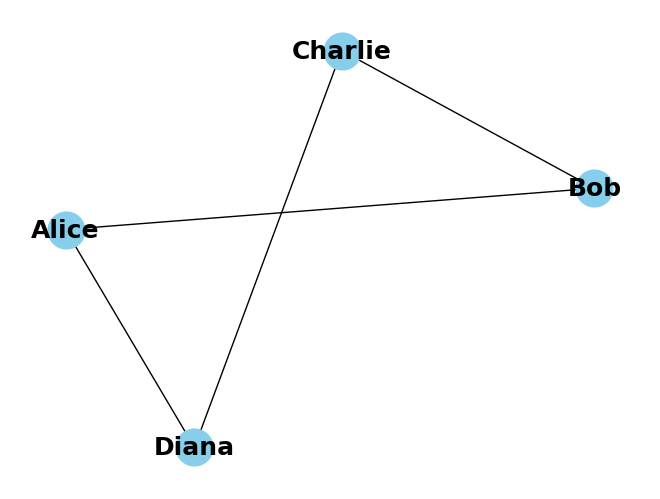

In [5]:
nx.draw(G, with_labels=True, font_weight='bold', node_color='skyblue', font_size=18, node_size=700)
plt.show()

## Step 2: Defining Spatial Coordinates Attributes 

We assign geographical coordinates to users.

In [6]:
# Assigning 2D coordinates to nodes.
coordinates = {"Alice": (1, 5), "Bob": (3, 2), "Charlie": (4, 4), "Diana": (2, 3)}
nx.set_node_attributes(G, coordinates, "coordinates")
nx.set_node_attributes(G, coordinates, 'pos')

We can develop a function to calculate the Euclidean distance between the coordinates of two nodes.

In [7]:
import math

def calculate_spatial_distance(G, node1, node2):
    x1, y1 = G.nodes[node1]["coordinates"]
    x2, y2 = G.nodes[node2]["coordinates"]
    
    distance = math.sqrt((x2 - x1)**2 + (y2 - y1)**2)
    return distance

We can compute spatial distances for all pairs of connected nodes.

In [8]:
spatial_distance = {}

for edge in G.edges:
    node1, node2 = edge
    spatial_dist = calculate_spatial_distance(G, node1, node2)
    print(f"The spatial distance between {node1} and {node2} is {spatial_dist}")
    spatial_distance[edge]=spatial_dist

nx.set_edge_attributes(G, spatial_distance, "spatial_distance")

The spatial distance between Alice and Bob is 3.605551275463989
The spatial distance between Alice and Diana is 2.23606797749979
The spatial distance between Bob and Charlie is 2.23606797749979
The spatial distance between Charlie and Diana is 2.23606797749979


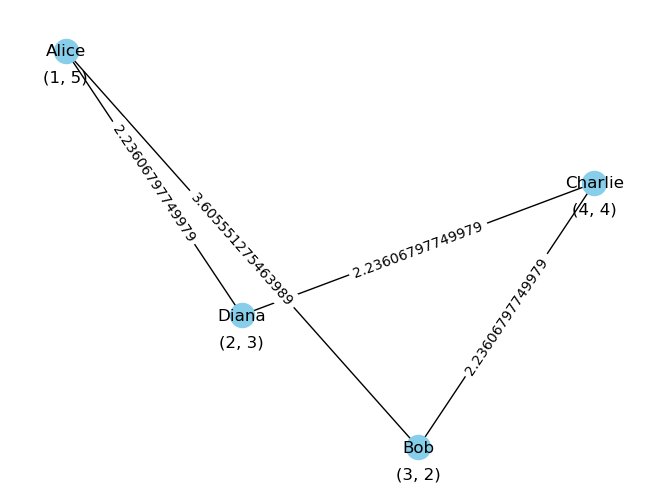

In [9]:
edge_labels = nx.get_edge_attributes(G, 'spatial_distance')
pos=nx.get_node_attributes(G,'pos')
pos_text = {key: (x, y-0.2) for key, (x, y) in pos.items()}
nx.draw(G,pos, with_labels=True, node_color='skyblue')
nx.draw_networkx_labels(G, pos_text, labels=pos)


nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)
plt.show()





## Step 3: Introducing Personalized Privacy Attributes 

Assign privacy budget to nodes to indicate the sensitivity of users' location data. The smaller the parameter, the stronger the privacy protection provided. **RANGE [0,1]**


**Personalized Privacy Budget**: $\epsilon(u)$, where $u$ is the user.  <br> 

Small $\epsilon$ (e.g., $\epsilon<1$): Such a setting provides strong privacy protection but may significantly reduce data utility. <br> 
Meduium $\epsilon$ (e.g., $1 \leq \epsilon \leq 3$): This is a commonly used range that strikes a balance between privacy and utility. <br>
Large $\epsilon$ (e.g., $\epsilon > 3$)Such a setting may increase the risk of privacy leakage but can yield more accurate query results. <br>


In [10]:
privacy_budgets = {"Alice": 1, "Bob": 10, "Charlie":2, "Diana": 3}
nx.set_node_attributes(G, privacy_budgets, "privacy_budget")

We assign trust scores to edges between user nodes. A higher score indicates that users are less cautious about sharing their location data with each other. **RANGE [0,1]**

**Trust Score between user $u$ and $v$**: $T(u)$. <br> 

In [11]:
trust_scores = {("Alice", "Bob"): 1, ("Bob", "Charlie"): 0.5, ("Charlie", "Diana"): 0.2, ("Diana", "Alice"): 0.3}
nx.set_edge_attributes(G, trust_scores, "trust_score")

## Step 4: Apply personalized DP to protect quried spatial distance

**Sensitivity**: $\Delta f$. For simplification, we let $\Delta f = 1$ in the following calculation. <br>
**Scale parameter of user $u$**: $\lambda(u)=\frac{\Delta f}{\epsilon(u)})$. <br> 
**Spatial Coordinates of user $u$**: $S(u)$. <br> 
**Noise**: $N(u)=\mathrm{Laplace}(\lambda(u))$ <br> 
**Published Noisy Coordinates**:$S'(u) = S(u) * T(u) + N(u)$ <br> 


In [12]:
def generate_personalized_laplace_noise(mu, sensitivity, privacy_budget):
    # Adjust the scale parameter b based on the trust score
    scale_parameter = sensitivity / privacy_budget
    return np.random.laplace(mu, scale_parameter, 1)[0]


We develop functions to generate noisy spatial coordinates and protected distance quried by users. Note that **only friends** can query their spatial distance.

In [13]:
def noise_coordinates(requested_user, querying_user):
    trust_score = G.get_edge_data(requested_user, querying_user)["trust_score"]
    actual_coords = coordinates[requested_user]
    # Reduce noise based on trust score
    noise_x, noise_y = generate_personalized_laplace_noise(0, 1, privacy_budgets[requested_user]), generate_personalized_laplace_noise(0, 1, privacy_budgets[requested_user])
    noisy_coords = (trust_score * actual_coords[0] +  noise_x, trust_score * actual_coords[1] +  noise_y)
    return noisy_coords


In [14]:
def calculate_protected_spatial_distance(querying_user, noisy_coordinates):
    actual_coords = coordinates[querying_user]
    x1, y1 = actual_coords # querying user's
    x2, y2 = noisy_coordinates # requested user's
    
    protected_distance = math.sqrt((x2 - x1)**2 + (y2 - y1)**2)
    return protected_distance

We can simulate the scenario that one user queries the spatial distance with his/her friend under personalized DP protection. 

Scenario: **Bob** (**querying user**) is querying its spatial distance with **Alice** (**requested user**).


In [15]:
random.seed(42)
np.random.seed(42)
privacy_budgets = {"Alice": 100, "Bob": 10, "Charlie":2, "Diana": 3}


requested_user = 'Alice'
querying_user = 'Bob'
noisy_coordinates = noise_coordinates(requested_user, querying_user)
actual_coordinates = coordinates[(requested_user)]
protected_distance = calculate_protected_spatial_distance(querying_user, noisy_coordinates)
print(f"Protected spatial distance between {requested_user} and {querying_user} queried by {querying_user}:", protected_distance)
actual_spatial_distance = calculate_spatial_distance(G, requested_user, querying_user)
print(f"Actual spatial distance between {requested_user} and {querying_user} is {actual_spatial_distance}")


Protected spatial distance between Alice and Bob queried by Bob: 3.626447298090962
Actual spatial distance between Alice and Bob is 3.605551275463989
